In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import random
import pandas as pd

In [3]:
p = pd.read_csv("../data/personen.csv", header=None)
personen = [p.iloc[i,0] for i in p.index]
personen

['Lokalhis-toriker*innen',
 'Historische Gesellschaft',
 'Pfarrer*innen',
 'notgeile alte Menschen',
 'weirde Aristokraten',
 'lokale Eigenbröd-ler*innen',
 'Dorfbewohner gegen.../ Villagers against ...',
 'religiöse Fanatiker*innen',
 'Antiquitäten-händler*innen',
 'Dorfarzt/-ärztin',
 'neugierige Nachbarn',
 'hormonelle Teenager',
 'Heiden',
 'Pferde',
 'Perverse']

In [6]:
[i for i in personen if i not in ["Heiden", "Pferde"]]

['Lokalhis-toriker*innen',
 'Historische Gesellschaft',
 'Pfarrer*innen',
 'notgeile alte Menschen',
 'weirde Aristokraten',
 'lokale Eigenbröd-ler*innen',
 'Dorfbewohner gegen.../ Villagers against ...',
 'religiöse Fanatiker*innen',
 'Antiquitäten-händler*innen',
 'Dorfarzt/-ärztin',
 'neugierige Nachbarn',
 'hormonelle Teenager',
 'Perverse']

In [4]:
def split_term(word, max_chars):
    if len(word) > max_chars:
        penalty = 0
        words = word.split(" ")
        longest_word = max([len(w) for w in words])

        if longest_word > max_chars:
            lw = [[idx, w] for idx, w in enumerate(words) if len(w) > max_chars]
            shift = [0*i for i in range(0,len(words))]
            for w in lw:
                if len(w[1]) > max_chars:
                    if "/" in w[1]:
                        w[1] = w[1].replace("/", "/ ", 1).split(" ", maxsplit=1)
                    elif "-" in w[1]:
                        w[1] = w[1].replace("-", "- ", 1).split(" ", maxsplit=1)
                    else:
                        penalty = max(len(w[1]) - max_chars, 0)
                        w[1] = [w[1]]
                
                if w[0] == 0:
                    shift[0] = len(w[1])-1
                    w[1].extend(words[1:])
                    words = w[1]
                else:
                    shift[w[0]] = len(w[1])-1
                    prev_shift = sum(shift[:w[0]])
                    words = words[:w[0]+prev_shift] + w[1] + words[w[0]+1+prev_shift:]

                    

        word_num = 1
        word_len = len(words[0])
        row_words = words[0]

        while word_num < len(words):
            if word_len + len(words[word_num]) < max_chars:
                word_len = word_len + len(words[word_num]) + 1
                row_words = row_words + " " + words[word_num]
                word_num = word_num + 1
            else:
                row_words = row_words + "\n" + words[word_num]
                word_len = len(words[word_num]) + 1
                word_num = word_num +1

        return row_words, penalty
    else:
        return word, 0

In [59]:
def create_bingo_card(card_number, rowlen, terms, output_dir="Bingo_Card"):
    terms_copy = terms.copy()
    random.shuffle(terms_copy)
    # Insert "Free" in the center
    terms_copy.insert((rowlen * rowlen) // 2, "Free")
    bingo_terms = terms_copy[:rowlen * rowlen]

    fig, ax = plt.subplots(figsize=(10,10))
    # ax.set_title("Barnaby BINGO", fontweight='bold', fontsize=25)
    ax.set_xticks(np.arange(0, rowlen + 1))
    ax.set_yticks(np.arange(0, rowlen + 1))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid(color='black', linewidth=1)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    
    for i, word in enumerate(bingo_terms):
        x = (i % rowlen) + 0.5
        y = (i // rowlen) + 0.5

        word, penalty = split_term(word, 18)
        
        base_fontsize = 18 if word == "Free" else 12
        fontsize = max(base_fontsize - penalty, 8)  # Set minimum fontsize
    
        ax.annotate(
            word,
            xy=(x, y),
            ha='center',
            va='center',
            fontsize=fontsize,
            fontweight='bold' if word == "Free" else 'normal',
            wrap=True
        )
    fig.add_artist(plt.Rectangle((2, 2), 1,1, alpha=0.5, transform=ax.transData))
    plt.tight_layout()
    return fig, ax
    # os.makedirs(output_dir, exist_ok=True)
    # fig.savefig(os.path.join(output_dir, f"{card_number:02d}-Bingo.png"))
    # plt.close(fig)

---

In [6]:
personen = [
    "Lokalhis-toriker*innen", 
    "Historische Gesellschaft", 
    "Pfarrer*innen", 
    "notgeile alte Menschen", 
    "weirde Aristokraten", 
    "lokale Eigenbröd-ler*innen", 
    "Dorfbewohner gegen.../ Villagers against ...", 
    "religiöse Fanatiker*innen", 
    "Antiquitäten-händler*innen", 
    "Dorfarzt/-ärztin", 
    "neugierige Nachbarn", 
    "hormonelle Teenager", 
    "Heiden", 
    "Pferde",
]
orte = [
    "Badgers Drift",
    "B&B",
    "Farm",
    "Herrenhaus",
    "Reiterhof",
    "Zirkus",
    "Midsomer Worthy",
    "Causton",
    "Fletchers Cross",
    "Aspen Tallow",

]

dinge = [
    "Oldtimer",
    "Kanalboote",
    "Nischenhobby (Fliegenfischen, Orchideen, ...)",
    "Geister",
    "Militär",
    "Schrotflinte",
    "Testament",
    "weirde Dorftradition",
    "Dorffeier/-event",
    "Lokalpolitik",
    "Beerdigung",
    "Jagd",
    "Familienfehde",
    "Affäre",
    "Wasser",
    "Cricket",
    "Lokalzeitung"
]

handlung_fall = [
    'Inzest',
    'Streit über Landansprüche',
    'Dorfevent bedroht durch Mord',
    'irgendetwas steht kurz vor der Insolvenz',
    'Pfarrer*in hat definitiv Dreck am Stecken',
    'Publeute haben definitiv Dreck am Stecken',
    'jemand wird erpresst',
    'Motiv: Erbe',
    'Motiv: Vertuschung vorheriger Morde',
    'Erbüberraschung',
    'jemand bekommt bedrohliche Briefe',
    'jemand hat kein Alibi',
    'reiche Menschen gar nicht so reich',
    'kaputtes Dach',
    'reiche Menschen respektieren Polizei nicht',
    'überraschende Enthüllung sexueller Orientierung',
    'Mann war nie zeugungsfähig',
    'uneheliche Kinder',
    'Totgeglaubte gar nicht tot',
    'jemand kehrt zurück ins Dorf',
    'letzte Worte à la "Was machst du denn hier?"',
    'nächstes Opfer wollte Täter*in erpressen',
    'Schuld eigen',
    'Opfer hat es irgendwie verdient',
    'niemand konnte Opfer leiden',
    'Witwe/r trauert zu 0%',
    'Mord während Telefonat',
    'jemandem wird eine Falle gestellt',
    'Mord vor dem Fernseher',
    'jemand wird eingesperrt',
    'jemand hat tatsächlich Suizid begangen',
    'die falsche Person wird umgebracht',
    'jemand überlebt einen Mordversuch',
    'alle Morde sind geplant',
    '"Unfall" war tatsächlich Mord',
    'extrem skurrile Mordmethode',
    'Showdown in der Kirche',
    'Gärtner*in ist Mörder*in',
    'Pfarrer*in ist Mörder*in',
    'Mord ist Familiensache',
    'alle sind kriminell',
    'min. 2 andere Straften ohne Bezug zum Mord',
    'jemand wird erstochen',
    'jemand wird erdrosselt',
    'jemand wird die Treppe runter geschubst',
    'Themen-Morde',
]

handlung_ermittlung = [
    'DS auf weltfalschester Fährte',
    'DS hat mit etwas recht',
    'DS macht Drecksarbeit',
    'DS flirtet mit Verdächtigen',
    'DS/DCI wird von Verdächtigen angegraben',
    'DS macht Notizen',
    'Gerichts-mediziner*in ist "lustig"',
    'Barnaby überlebt nur, weil die Autoren es so wollen',
    'Barnaby muss rennen (unfreiwillig)',
    'Durchsuchungs-beschluss optional',
    'notarielle Schweigepflicht gilt nicht für Barnaby',
    'Beweismittel-sicherung ist ein Fremdwort',
    'zufällige Lösung eines alten Falls',
    'Fall durch nebensächliches Ereignis gelöst',
    'Barnaby hat einen Heureka-Moment',
]

handlung_sonstiges = [
    'Pub während der Arbeitszeit',
    'Alkohol während der Arbeitszeit',
    'Joyce/Cully/Sarah sind aktiv beteiligt',
    'Joyce/Sarah hat ein neues Hobby = Mord',
    'freier Tag, was das?',
    'Feierabend = Alkohol',
    'Joyce kocht, Barnaby schafft es irgendwie, nichts essen zu müssen',
    'Barnaby auf Diät',
    'Cully hat ein Casting',
    'Cully hat einen neuen Job',
]

tatsachen = [
    'die Barnabys führen die einzig funktionierende Beziehung',
    'Paar mag sich, beide überleben, beide unschuldig',
    'niemand kann Auto fahren',
    'DS trägt sehr laute Krawatte',
]

meta = [
    'Mama kennt es nicht, ALLE anderen wissen wer es war',
    'Maria weiß wie alle sterben, aber nicht wers war',
    'erster Mord nach 30 Minuten',
    '3 1/2 Morde',
    'Flashback',
    'Mord-Kamera (schwarze Handschuhe, ...)',
    'Episodenende im Pub/Biergarten',
    'Szene endet vor Erklärung wichtiger Ereignisse',
    'jemand auf einem Fahrrad',
    'jemand macht nächtlichen Spaziergang',
    'offene Haustür',
    'Variation des Intros live gespielt',
    'schöne Szenerie',
    'recycelter Drehort',
    'berühmte Person',
    '100% weißer Cast',
]

meh = [
    'Familie beinahe ausgerottet',
]

terms = personen + orte + dinge + handlung_fall + handlung_ermittlung +  handlung_sonstiges + tatsachen + meta

In [149]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import scipy.ndimage as ndimage
def load_stamp():
    arr_img = plt.imread("./data/mm_yellow.png")
    arr_img = ndimage.rotate(arr_img, 45, reshape=True);
    im = OffsetImage(arr_img, zoom=0.03);
    return AnnotationBbox(im, (1.5, 1.5), xycoords='data', frameon=False, box_alignment=(0.5,0.5));

stamp = load_stamp()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.29223228..1.2280245].


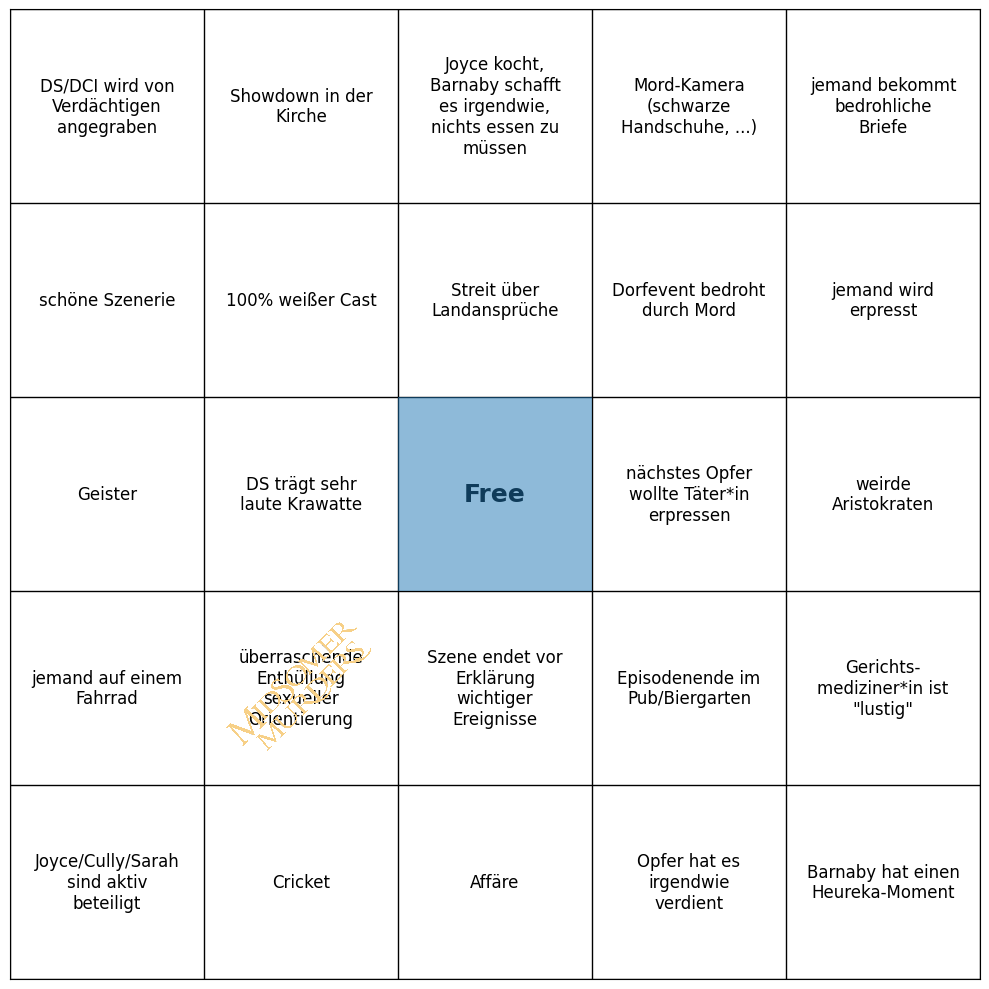

In [150]:
fig, ax = create_bingo_card(1, 5, terms)
ax.add_artist(stamp);

In [151]:
for i, artist in enumerate(ax.artists):
    print(artist.xy)

(1.5, 1.5)


In [ ]:
xy_stuff = [[i, artist.get_xy()] for i, artist in enumerate(fig.artists)]
for stuff in xy_stuff:
    if stuff[1] == (2,2) 

yay


In [46]:
for i in range(1,4):
    create_bingo_card(i, 5, terms)